Jumlah data: 1000


,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None

Jumlah missing value:
review    0
label     0
dtype: int64

Distribusi label:
label
0    500
1    500
Name: count, dtype: int64


,review,label,clean_review
0,So there is no way for me to plug it in here i...,0,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",1,good case excellent value
2,Great for the jawbone.,1,great for the jawbone
3,Tied to charger for conversations lasting more...,0,tied to charger for conversations lasting more...
4,The mic is great.,1,the mic is great


Jumlah data training: 800
Jumlah data testing: 200
Training selesai.
Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.76      0.76       100
    Positive       0.76      0.76      0.76       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200



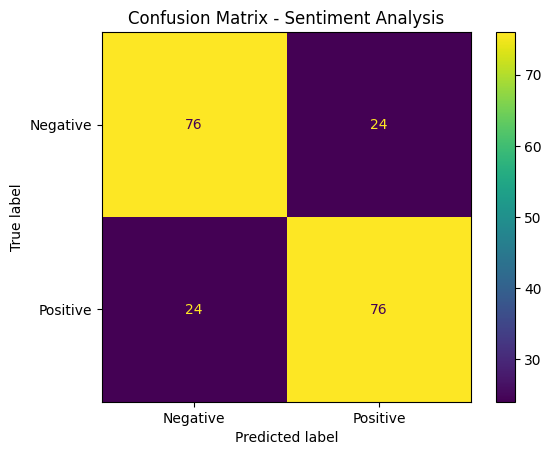

I dont like this web => Negative
I love this phone, battery lasts forever! => Positive
This product is very bad => Negative
The quality is excellent and worth the price => Positive
Model dan vectorizer berhasil disimpan.


In [ ]:
# ===============================
# ANALISIS SENTIMEN AMAZON REVIEW
# TF-IDF + LOGISTIC REGRESSION
# ===============================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import joblib

# ===============================
# 1. LOAD DATASET
# ===============================

df = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    names=["review", "label"]
)

print("Jumlah data:", len(df))
display(df.head())

# ===============================
# 2. CEK DATA
# ===============================

print(df.info())
print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

# ===============================
# 3. PREPROCESSING TEXT
# ===============================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

display(df.head())

# ===============================
# 4. SPLIT DATA
# ===============================

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

# ===============================
# 5. TF-IDF VECTORIZATION
# ===============================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ===============================
# 6. TRAINING MODEL
# ===============================

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Training selesai.")

# ===============================
# 7. EVALUASI MODEL
# ===============================

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

# ===============================
# 8. CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

# ===============================
# 9. FUNGSI PREDIKSI SENTIMEN
# ===============================

def sentiment_pred(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

# ===============================
# 10. CONTOH PREDIKSI
# ===============================

test_sentences = [
    "I dont like this web",
    "I love this phone, battery lasts forever!",
    "This product is very bad",
    "The quality is excellent and worth the price"
]

for sentence in test_sentences:
    print(sentence, "=>", sentiment_pred(sentence))

# ===============================
# 11. SIMPAN MODEL
# ===============================

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model dan vectorizer berhasil disimpan.")

In [ ]:
%%writefile app.py

import streamlit as st
import joblib
import re

model = joblib.load("sentiment_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def sentiment_pred(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    return "POSITIVE" if prediction == 1 else "NEGATIVE"

st.title("🔍 Sentiment Analysis App")
st.write("Masukkan kalimat review produk Amazon untuk melihat prediksi sentimennya.")

user_input = st.text_area("Masukkan teks ulasan di sini:")

if st.button("Prediksi Sentimen"):
    if user_input.strip() == "":
        st.warning("Silakan masukkan teks terlebih dahulu.")
    else:
        result = sentiment_pred(user_input)

        if result == "POSITIVE":
            st.success("✅ Sentiment: POSITIVE 😊")
        else:
            st.error("❌ Sentiment: NEGATIVE 😞")

Writing app.py
